# Probability Distributions

Antonio Esteves, Jan 2024

## Discrete Probability Distributions

### 1. Binomial Distribution

In [131]:
from   scipy.stats import binom
import seaborn as sns

N = 10
data = binom.rvs(n=N,p=0.3,size=100)

print(f'Skewed towards 0 (p=0.3):\n{data}')

data = binom.rvs(n=N,p=0.7,size=100)

print(f'Skewed towards {N} (p=0.7):\n{data}')

Skewed towards 0 (p=0.3):
[5 4 2 4 2 6 3 1 4 3 3 2 4 4 5 2 3 3 3 2 3 1 4 4 3 1 2 2 3 2 3 2 5 2 0 4 1
 1 5 1 5 1 4 5 3 5 3 3 3 4 1 2 2 3 5 3 2 1 0 1 3 2 1 3 5 2 4 1 4 4 1 4 2 3
 3 0 2 4 2 4 1 4 2 2 3 4 2 3 5 4 2 4 3 3 2 7 2 2 1 3]
Skewed towards 10 (p=0.7):
[ 8  6  7  6  5  8  7  5  6  9  6  9  6  9  6  8  9  6  5  8  7  7  8  5
  7  6  9  7  6 10  6  5  6  6  7  6  8  7  7  7  9  9  8  7  7  7  7  5
  8  8  8  6  6  8  8  6  7  7  9  7  6  7  9  8  8  8  7  9  8  6  7  9
  6  8  7  7  5  7 10  6  6  6  7  9  9  8  9  5 10  7  6  8  7  7  7  8
  6  6  6  6]


                        p=0.3    p=0.7
                        -----    -----
Distribution mean:      3.00     7.00
Sample mean:            3.02     6.99
Distribution variance:  2.10     2.10
Sample variance:        2.11     2.12


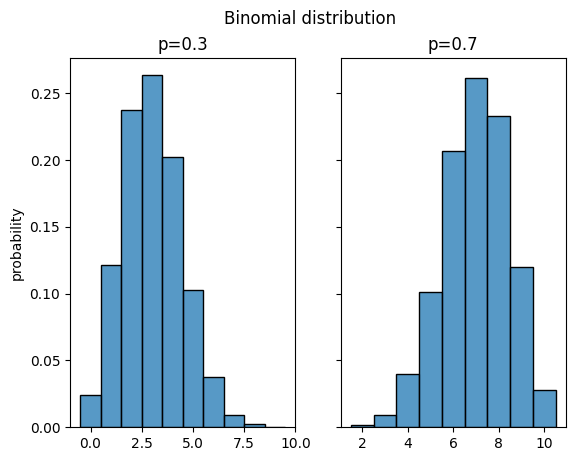

In [203]:
from   scipy.stats import binom
import seaborn as sns

N    = 10
SIZE = 10000

data_p03    = binom.rvs(n=N, p=0.3, size=SIZE)
data_p03_df = pd.DataFrame({'x':data_p03})
data_p07    = binom.rvs(n=N, p=0.7, size=SIZE)
data_p07_df = pd.DataFrame({'x':data_p07})

print(f'                        p=0.3    p=0.7')
print(f'                        -----    -----')
print(f'Distribution mean:      {binom.mean(n=N,p=0.3, loc=0):.2f}     {binom.mean(n=N,p=0.7, loc=0):.2f}')
print(f'Sample mean:            {np.mean(data_p03):.2f}     {np.mean(data_p07):.2f}')
print(f'Distribution variance:  {binom.var(n=N,p=0.3, loc=0):.2f}     {binom.var(n=N,p=0.7, loc=0):.2f}')
print(f'Sample variance:        {np.var(data_p03):.2f}     {np.var(data_p07):.2f}')

fig, ax = plt.subplots(nrows=1, ncols=2, sharey=True)

sns.histplot(ax=ax[0], data=data_p03, stat='probability', bins=N, discrete=True)
ax[0].set(title='p=0.3', ylabel='probability')

sns.histplot(ax=ax[1], data=data_p07, stat='probability', bins=N, discrete=True)
ax[1].set(title='p=0.7', ylabel='probability')

fig.suptitle('Binomial distribution')
plt.show()


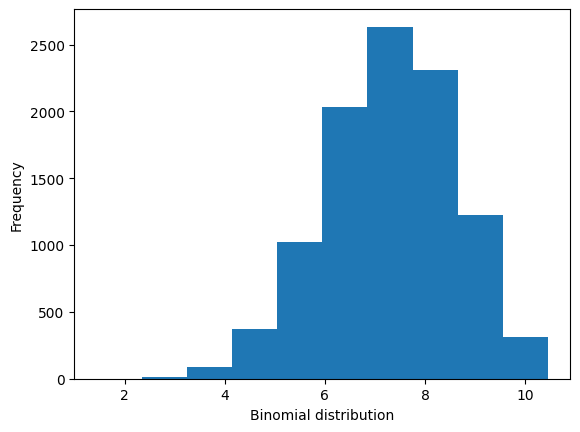

In [150]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(nrows=1, ncols=1)
ax.hist(data, bins=N, align='right')
ax.set_xlabel('Binomial distribution')
ax.set_ylabel('Frequency')
plt.show()

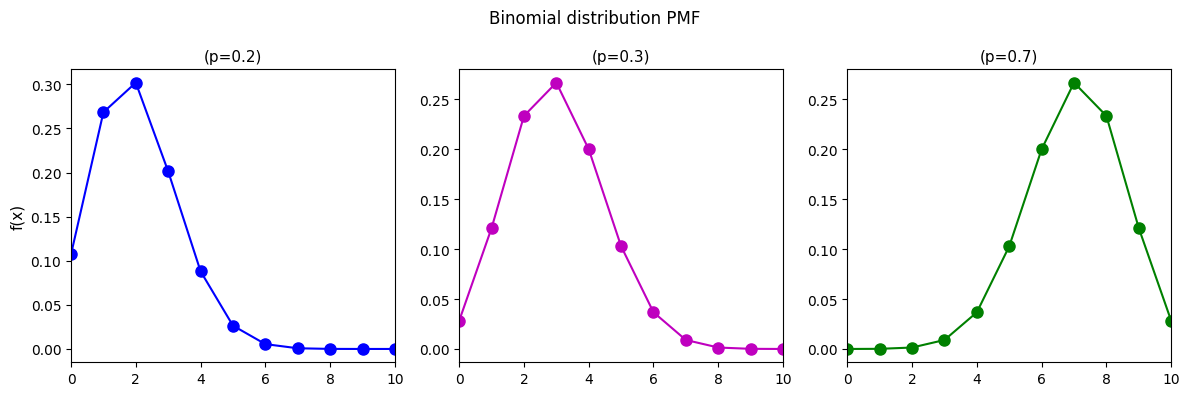

In [44]:
import numpy as np
from   scipy.stats import binom
import matplotlib.pyplot as plt

n      = 10
p_arr  = [0.2, 0.3, 0.7]
color  = ['b', 'm', 'g']
nrows  = 1
ncols  = 3

fig, ax = plt.subplots(nrows, ncols, figsize=(12,4))

# Display the probability density functions
for nc in range(ncols):
    x = np.arange(0,n+1)
    ax[nc].plot(
        x, 
        binom.pmf(x, n=n, p=p_arr[nc]),
        color=color[nc], 
        markerfacecolor=color[nc],
        markeredgecolor=color[nc],
        marker='o',
        ms=8,
        label=f'pmf p={p_arr[nc]}'
    )
    ax[nc].set_xlim([x[0], x[-1]])
    if nc==0:
        ax[nc].set_ylabel('f(x)', fontsize=11)
    if nr==nrows-1:
        ax[nc].set_xlabel('x', fontsize=11)
    ax[nc].set_title(
        f'(p={p_arr[nc]})', fontsize=11
    )
fig.suptitle(f'Binomial distribution PMF')
#plt.legend(loc='upper right', fontsize= 12)
plt.show()

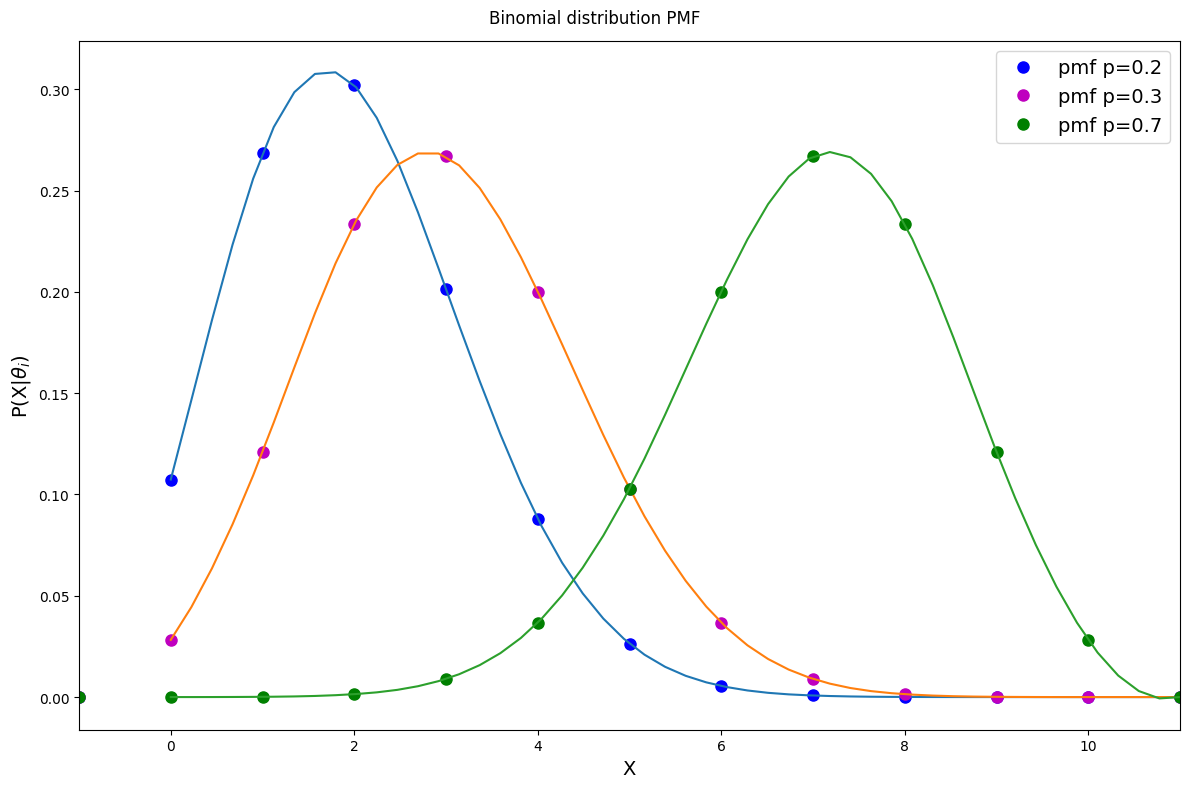

In [41]:
import numpy as np
from   scipy.stats import binom
import matplotlib.pyplot as plt

n      = 10
p_arr  = [0.2, 0.3, 0.7]
color  = ['b', 'm', 'g']
nrows  = 1
ncols  = 1
style  = ['bo', 'mo', 'go']

fig, ax = plt.subplots(nrows, ncols, figsize=(12,8))

# Display the probability density functions
for nc in range(len(p_arr)):
    x = np.arange(-1,n+2)
    y = binom.pmf(x, n=n, p=p_arr[nc])
    style
    ax.plot(
        x, 
        y,
        style[nc],
        ms=8,
        label=f'pmf p={p_arr[nc]}'
    )
    # x_new, bspline, y_new
    x_new   = np.linspace(0, n+1, 50)
    bspline = interpolate.make_interp_spline(x, y)
    y_new   = bspline(x_new)
    plt.plot(x_new, y_new)

    ax.set_xlim([x[0], x[-1]])
    ax.set_ylabel(r"P(X|$\theta_i$)", fontsize=14)
    ax.set_xlabel('X', fontsize=14)
    
fig.suptitle(f'Binomial distribution PMF')
plt.legend(loc='upper right', fontsize= 14)
plt.show()

### 2. Bernoulli Distribution

[Text(0.5, 1.0, 'Bernoulli distribution'), Text(0, 0.5, 'probability')]

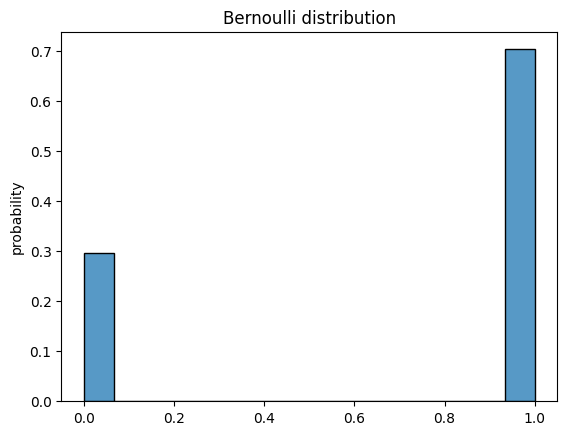

In [206]:
from scipy.stats import bernoulli

data    = bernoulli.rvs(size=10000, p=0.7)
data_df = pd.DataFrame({'x':data})

# visualization with seaborn

fig, ax = plt.subplots(nrows=1, ncols=1)
sns.histplot(data=data, stat='probability')
ax.set(title='Bernoulli distribution', ylabel='probability')


### 3. Multinomial Distribution

In [ ]:
from scipy.stats import multinomial

N = 10
k = 3
sample = multinomial.rvs(n=N, p=[0.5, 0.2, 0.3], size=100)
for j in range(k):
    print(f'S[j]:\n{sample[:,j]}')
    
print(f'SAMPLE:\n{sample}')

Text(0.5, 0.98, 'Multinomial distribution')

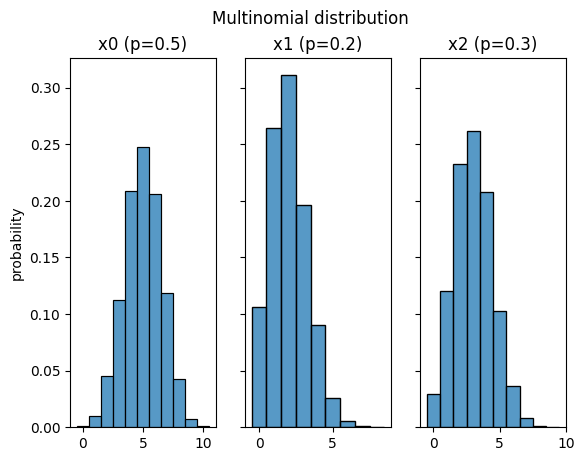

In [207]:
from scipy.stats import multinomial

N = 10
k = 3
prob   = [0.5, 0.2, 0.3]
sample = multinomial.rvs(n=N, p=prob, size=10000)

# visualization with seaborn

fig, ax = plt.subplots(nrows=1, ncols=k, sharey=True)
for j in range(k):
    sns.histplot(ax=ax[j], data=sample[:,j], stat='probability', bins=N, discrete=True)
    ax[j].set(title=f'x{j} (p={prob[j]})', ylabel='probability')

fig.suptitle('Multinomial distribution')


Text(0.5, 0.98, 'Multinomial distribution')

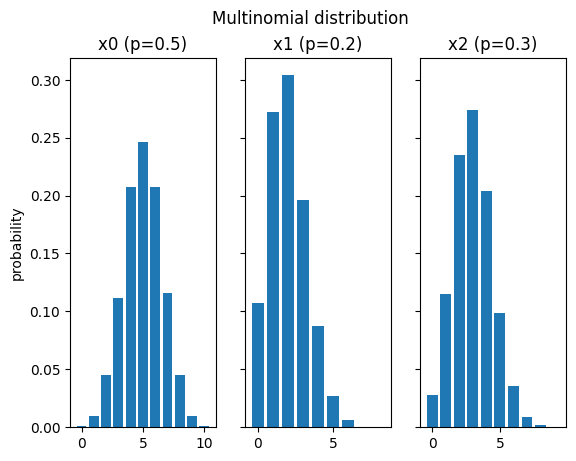

In [196]:
from scipy.stats import multinomial

N = 10
k = 3
prob   = [0.5, 0.2, 0.3]
sample = multinomial.rvs(n=N, p=prob, size=10000)

fig, ax = plt.subplots(nrows=1, ncols=k, sharey=True)

for j in range(k):
    values, counts = np.unique(sample[:,j], return_counts=True)
    probs = counts / counts.sum()

    # visualization with seaborn
    ax[j].bar(values, probs)
    y_label = 'probability' if j==0 else ''
    ax[j].set(title=f'x{j} (p={prob[j]})', ylabel=y_label)

fig.suptitle('Multinomial distribution')


### 4. Poisson Distribution

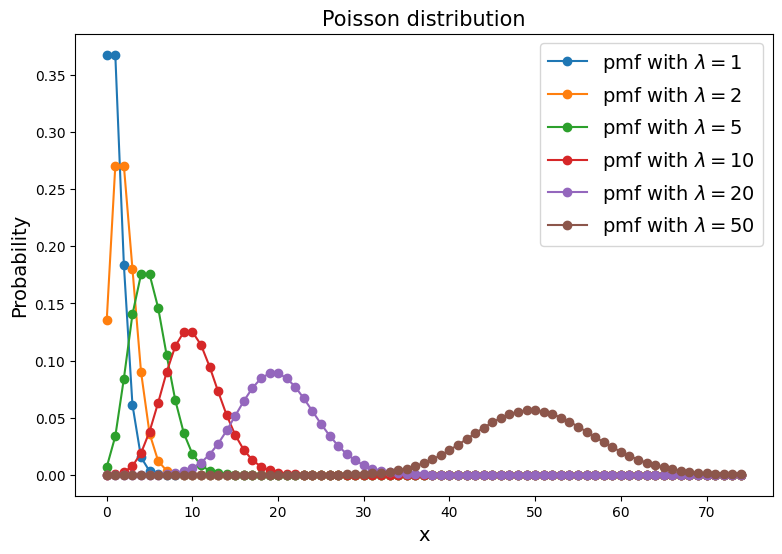

In [71]:
from scipy.stats import poisson

lambdas = [1, 2, 5, 10, 20, 50]
x = np.arange(0, 75)

plt.figure(figsize=(9, 6))

for lam in lambdas:
    poisson_dist = poisson.pmf(x, lam)
    plt.plot(x, poisson_dist, marker = 'o',
             label = r"pmf with $\lambda=$" + str(lam))

plt.xlabel('x', fontsize=14)
plt.ylabel('Probability', fontsize=14)
#plt.xlim([-1, 9])
plt.title("Poisson distribution", fontsize= 15)
plt.legend(loc='best', fontsize= 14)
plt.show()

Text(0.5, 0.98, 'Poisson distribution')

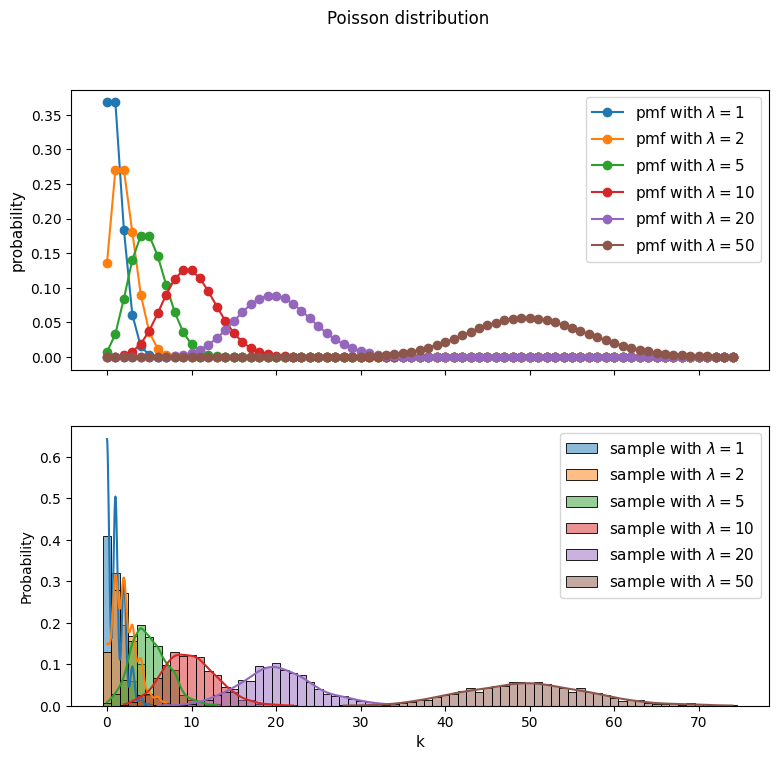

In [74]:
from scipy.stats import poisson

lambdas = [1, 2, 5, 10, 20, 50]
x       = np.arange(0, 75)

fig = plt.figure(figsize=(9, 8))
ax  = fig.subplots(nrows=2, ncols=1, sharex=True)

for j in range(len(lambdas)):
    dist = poisson.pmf(x, lambdas[j])
    ax[0].plot(x,dist, marker = 'o', label = r"pmf with $\lambda=$" + f'{lambdas[j]}')
    ax[0].set_ylabel('probability', fontsize=11)
    
    sample = poisson.rvs(mu=lambdas[j], size=1000) 
    sns.histplot(ax=ax[1], data=sample, stat='probability', discrete=True, kde=True, label=r"sample with $\lambda=$" + f'{lambdas[j]}')
    ax[1].set_xlabel('k', fontsize=11)

ax[0].legend(loc='best', fontsize= 11)
ax[1].legend(loc='best', fontsize= 11)
fig.suptitle('Poisson distribution')


### 5. Discrete uniform distribution

Probability: 0.0588


Text(0.5, 0.98, 'Discrete Uniform distribution')

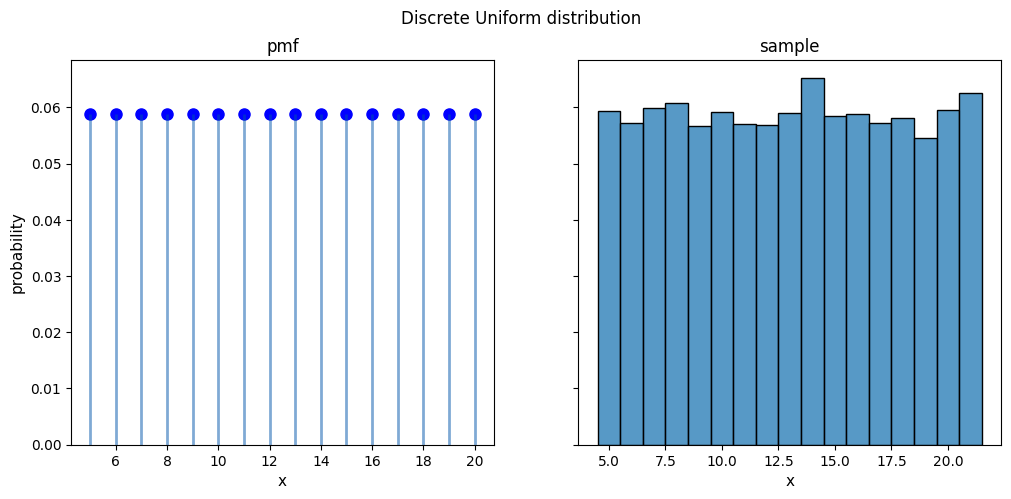

In [31]:
import numpy as np
from   scipy.stats import randint
import matplotlib.pyplot as plt
import seaborn as sns

l, h = 5, 21

prob = 1/(h-l+1)
print(f'Probability: {prob:.4f}')
x = np.arange(randint.ppf(0.01, l, h+1), randint.ppf(0.99, l, h+1))

# Generate random values
sample = randint.rvs(l, h+1, size=10000)

fig, ax = plt.subplots(1, 2, sharey=True, figsize=(12,5))

# Display the probability mass function
ax[0].plot(x, randint.pmf(x, l, h+1), 'bo', ms=8, label='DU pmf')
ax[0].vlines(x, 0, randint.pmf(x, l, h+1), colors='#0055AA', lw=2, alpha=0.5)
ax[0].set_ylabel('probability', fontsize=11)
ax[0].set_xlabel('x', fontsize=11)
ax[0].set_title('pmf')

# Display the random sample
sns.histplot(ax=ax[1], data=sample, stat='probability', discrete=True)
ax[1].set_xlabel('x', fontsize=11)
ax[1].set_title('sample')
fig.suptitle('Discrete Uniform distribution')

### 6. Uniform Distribution

Text(0.5, 0.98, 'Uniform distribution')

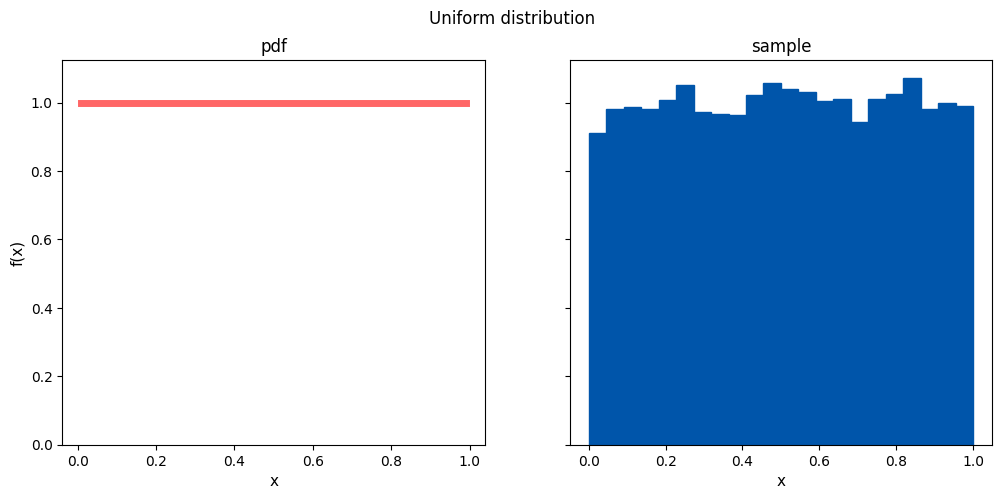

In [58]:
import numpy as np
from   scipy.stats import uniform
import matplotlib.pyplot as plt

# Display the probability density function (PDF)

x = np.linspace(uniform.ppf(0.01), uniform.ppf(0.99), 100)

# generate random numbers from the uniform distribution 
n     = 10000 
start = 0 
width = 1 
sample = uniform.rvs(size=n, loc = start, scale=width)

fig, ax = plt.subplots(1, 2, sharey=True, figsize=(12,5))

# Display the probability density function
ax[0].plot(x, uniform.pdf(x), 'r-', lw=5, alpha=0.6, label='pdf')
#ax[0].vlines(x, 0, randint.pmf(x, l, h+1), colors='#0055AA', lw=2, alpha=0.5)
ax[0].set_ylabel('f(x)', fontsize=11)
ax[0].set_xlabel('x', fontsize=11)
ax[0].set_title('pdf')

# Display the random sample
sns.histplot(ax=ax[1], data=sample, stat='density', discrete=False, kde=False,
    facecolor='#0055AA', edgecolor='#0055AA')
ax[1].set_xlabel('x', fontsize=11)
ax[1].set_title('sample')
fig.suptitle('Uniform distribution')

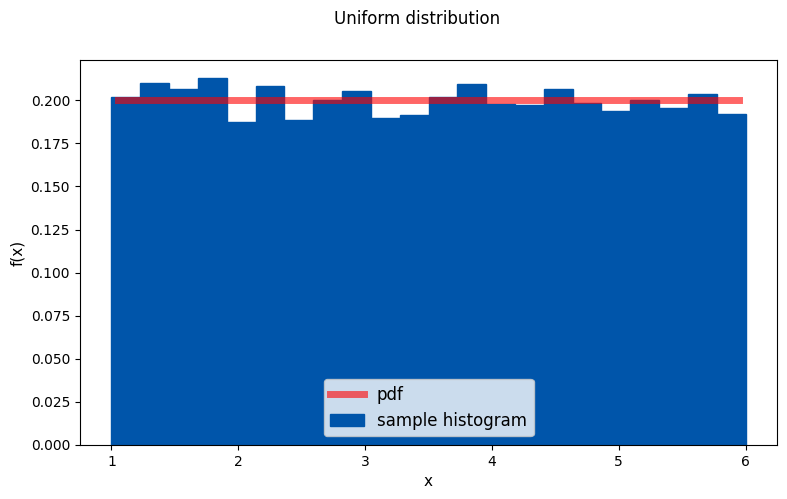

In [24]:
import numpy as np
from   scipy.stats import uniform
import matplotlib.pyplot as plt

# uniform distribution in support [low:low-width]
n      = 10000 
low    = 1 
width  = 5 

x = np.linspace(uniform.ppf(0.01, loc=low, scale=width), uniform.ppf(0.99, loc=low, scale=width), 100)

# generate random numbers from the uniform distribution
sample = uniform.rvs(size=n, loc=low, scale=width)

fig, ax = plt.subplots(1, 1, figsize=(9,5))

# Display the probability density function
ax.plot(x, uniform.pdf(x, loc=low, scale=width), 'r-', lw=5, alpha=0.6, label='pdf')
ax.set_ylabel('f(x)', fontsize=11)
ax.set_xlabel('x', fontsize=11)

# Display the random sample histogram
sns.histplot(ax=ax, data=sample, stat='density', discrete=False, kde=False,
            facecolor='#0055AA', edgecolor='#0055AA', label='sample histogram')
fig.suptitle('Uniform distribution')
plt.legend(loc='lower center', fontsize= 12)

### 7. Normal Distribution

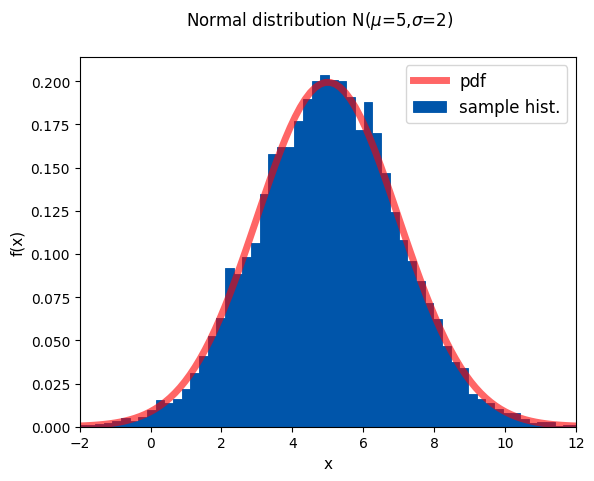

In [25]:
import numpy as np
from   scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns

mean    = 5
std_dev = 2

fig, ax = plt.subplots(1, 1)

# Display the probability density function 
x = np.linspace(mean-3.5*std_dev,mean+3.5*std_dev, 100)
ax.plot(x, norm.pdf(x, loc=mean, scale=std_dev), 'r-', lw=5, alpha=0.6, label='pdf')

# generate random numbers from N(mean,std_dev) 
sample = norm.rvs(size=10000, loc=mean, scale=std_dev)

# plot the sample histogram
ax.set_xlim([x[0], x[-1]])
sns.histplot(ax=ax, data=sample, stat='density', discrete=False, kde=False,
            facecolor='#0055AA', edgecolor='#0055AA', label='sample hist.')
ax.set_ylabel('f(x)', fontsize=11)
ax.set_xlabel('x', fontsize=11)
fig.suptitle(f'Normal distribution N($\mu$={mean},$\sigma$={std_dev})')
plt.legend(loc='upper right', fontsize= 12)
plt.show()

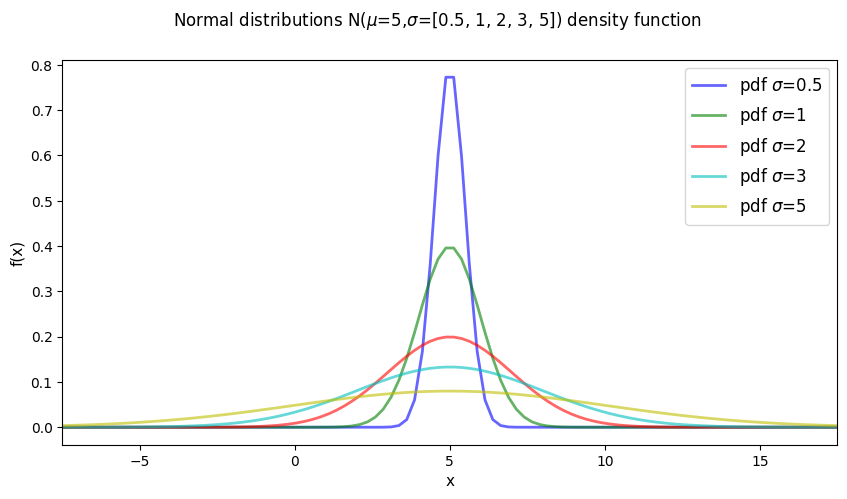

In [7]:
import numpy as np
from   scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns

mean    = 5
std_dev = [0.5, 1, 2, 3, 5]
color   = ['b', 'g', 'r', 'c', 'y']
fig, ax = plt.subplots(1, 1, figsize=(10,5))

x = np.linspace(mean-2.5*std_dev[-1],mean+2.5*std_dev[-1], 100)

# Display the probability density functions
for s, std in enumerate(std_dev):
    ax.plot(x, norm.pdf(x, loc=mean, scale=std), color=color[s], lw=2, alpha=0.6, label=f'pdf $\sigma$={std}')

# generate random numbers from N(mean,std_dev) 

# plot the sample histogram
ax.set_xlim([x[0], x[-1]])
ax.set_ylabel('f(x)', fontsize=11)
ax.set_xlabel('x', fontsize=11)
fig.suptitle(f'Normal distributions N($\mu$={mean},$\sigma$={std_dev}) density function')
plt.legend(loc='upper right', fontsize= 12)
plt.show()

### 8. Gamma Distribution

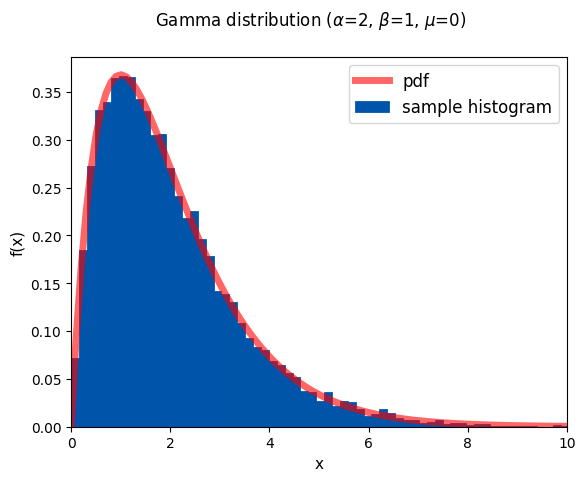

In [23]:
import numpy as np
from   scipy.stats import gamma
import matplotlib.pyplot as plt
import seaborn as sns

alpha  = 2
beta   = 1
mu     = 0

fig, ax = plt.subplots(1, 1)

# Display the probability density function 
x = np.linspace(0, 10, 100)
ax.plot(x, gamma.pdf(x, a=alpha, loc=mu, scale=(1/beta)), 'r-', lw=5, alpha=0.6, label='pdf')

# generate random numbers from gamma(alpha,beta,mu) 
sample = gamma.rvs(size=10000, a=alpha, loc=mu, scale=(1/beta))

# plot the sample histogram
ax.set_xlim([x[0], x[-1]])
sns.histplot(ax=ax, data=sample, stat='density', discrete=False, kde=False,
            facecolor='#0055AA', edgecolor='#0055AA', label='sample histogram')
ax.set_ylabel('f(x)', fontsize=11)
ax.set_xlabel('x', fontsize=11)
fig.suptitle(f'Gamma distribution ($\\alpha$={alpha}, $\\beta$={beta}, $\\mu$={mu})')
plt.legend(loc='upper right', fontsize= 12)
plt.show()

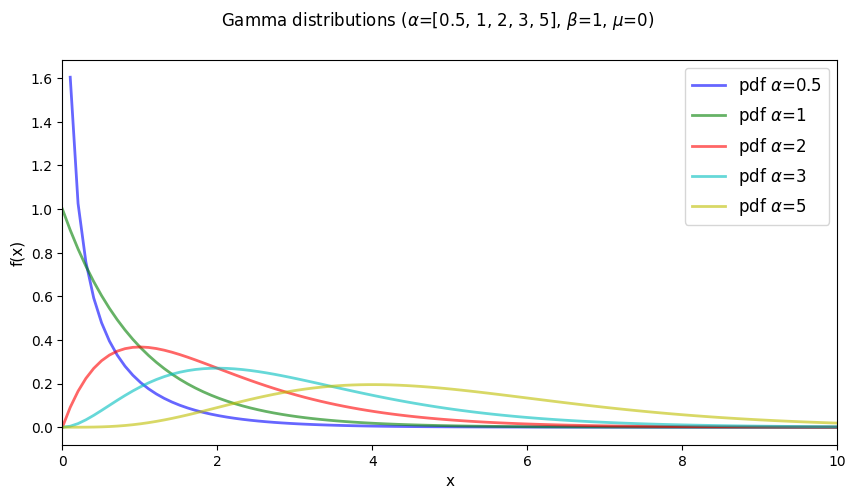

In [13]:
import numpy as np
from   scipy.stats import gamma
import matplotlib.pyplot as plt
import seaborn as sns

alpha  = [0.5, 1, 2, 3, 5]
beta   = 1
mu     = 0
color   = ['b', 'g', 'r', 'c', 'y']
fig, ax = plt.subplots(1, 1, figsize=(10,5))

x = np.linspace(0, 10, 100)

# Display the probability density functions
for n, a in enumerate(alpha):
    ax.plot(x, gamma.pdf(x, a=a, loc=mu, scale=(1/beta)), color=color[n], lw=2, alpha=0.6, label=f'pdf $\\alpha$={a}')

ax.set_xlim([x[0], x[-1]])
ax.set_ylabel('f(x)', fontsize=11)
ax.set_xlabel('x', fontsize=11)
fig.suptitle(f'Gamma distributions ($\\alpha$={alpha}, $\\beta$={beta}, $\\mu$={mu})')
plt.legend(loc='upper right', fontsize= 12)
plt.show()

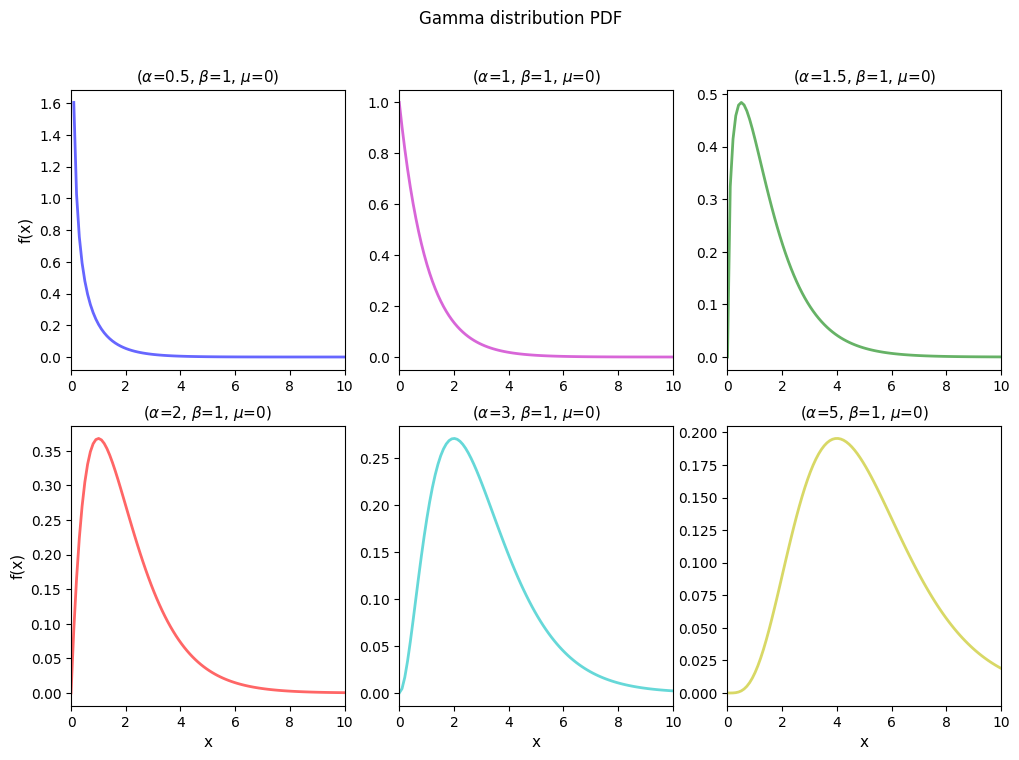

In [2]:
import numpy as np
from   scipy.stats import gamma
import matplotlib.pyplot as plt
import seaborn as sns

alpha  = [[0.5, 1, 1.5], [2, 3, 5]]
beta   = 1
mu     = 0
color  = [['b', 'm', 'g'], ['r', 'c', 'y']]
nrows  = 2
ncols  = 3

fig, ax = plt.subplots(nrows, ncols, figsize=(12,8))
x = np.linspace(0, 10, 100)

# Display the probability density functions
for nr in range(nrows):
    for nc in range(ncols):
        ax[nr][nc].plot(
            x, 
            gamma.pdf(x, a=alpha[nr][nc], loc=mu, scale=(1/beta)),
            color=color[nr][nc], 
            lw=2, 
            alpha=0.6, 
            label=f'pdf $\\alpha$={alpha[nr][nc]}'
        )
        ax[nr][nc].set_xlim([x[0], x[-1]])
        if nc==0:
            ax[nr][nc].set_ylabel('f(x)', fontsize=11)
        if nr==nrows-1:
            ax[nr][nc].set_xlabel('x', fontsize=11)
        ax[nr][nc].set_title(
            f'($\\alpha$={alpha[nr][nc]}, $\\beta$={beta}, $\\mu$={mu})', fontsize=11
        )
fig.suptitle(f'Gamma distribution PDF')
#plt.legend(loc='upper right', fontsize= 12)
plt.show()

### 9. Beta Distribution

PDF -> beta.pdf(x,a_scipy,b_scipy,loc,scale)

* a     (scipy) = p
* b     (scipy) = q
* loc   (scipy) = a
* scale (scipy) = b-a


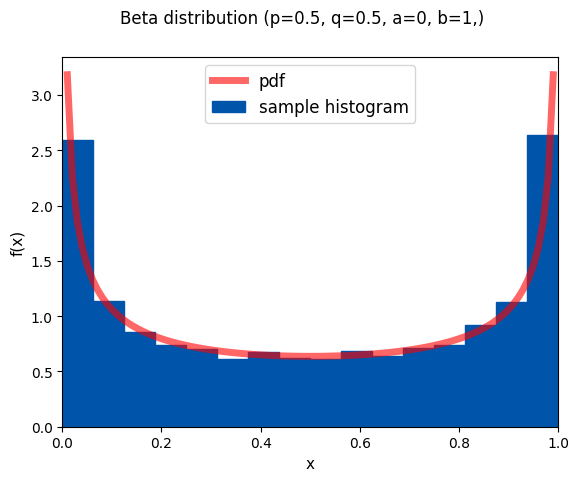

In [31]:
import numpy as np
from   scipy.stats import beta
import matplotlib.pyplot as plt
import seaborn as sns

a = 0   # lower bound (standard beta distribution)
b = 1   # upper bound (standard beta distribution)
p = 0.5 # shape parameter
q = 0.5 # shape parameter

a_scipy = p
b_scipy = q
loc     = a
scale   = b-a

fig, ax = plt.subplots(1, 1)

# Display the probability density function 
x = np.linspace(a, b, 100)
ax.plot(x, beta.pdf(x, a=a_scipy, b=b_scipy, loc=loc, scale=scale), 'r-', lw=5, alpha=0.6, label='pdf')

# generate random numbers from beta(p, q, a, b) 
sample = beta.rvs(size=10000, a=a_scipy, b=b_scipy, loc=loc, scale=scale)

# plot the sample histogram
ax.set_xlim([x[0], x[-1]])
sns.histplot(ax=ax, data=sample, stat='density', discrete=False, kde=False,
            facecolor='#0055AA', edgecolor='#0055AA', label='sample histogram')
ax.set_ylabel('f(x)', fontsize=11)
ax.set_xlabel('x', fontsize=11)
fig.suptitle(f'Beta distribution (p={p}, q={q}, a={a}, b={b},)')
plt.legend(loc='upper center', fontsize= 12)
plt.show()

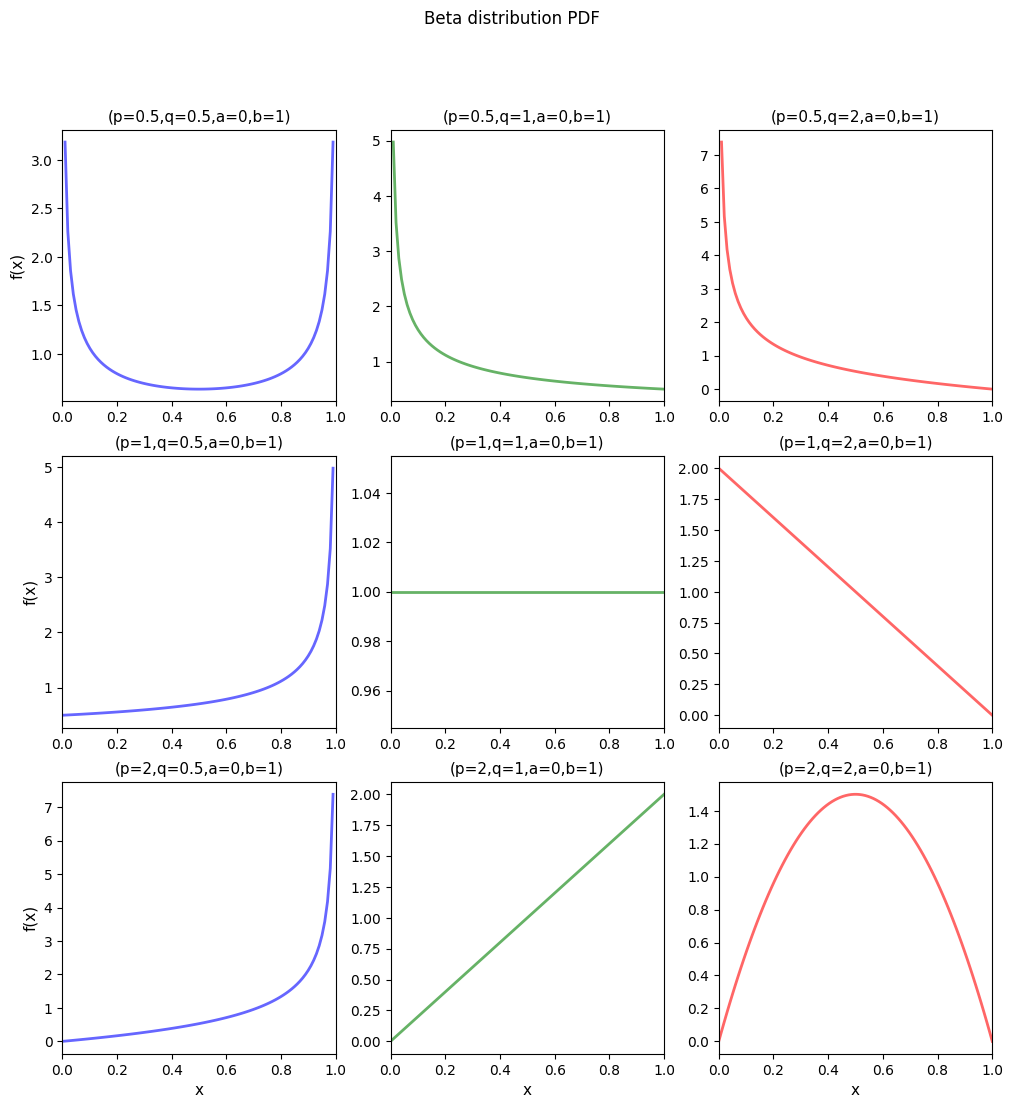

In [37]:
import numpy as np
from   scipy.stats import beta
import matplotlib.pyplot as plt
import seaborn as sns

a   = 0   # lower bound (standard beta distribution)
b   = 1   # upper bound (standard beta distribution)
p   = [[0.5, 0.5, 0.5], [1, 1, 1], [2, 2, 2]]
q   = [[0.5, 1, 2], [0.5, 1, 2], [0.5, 1, 2]]

color  = [['b', 'g', 'r'], ['b', 'g', 'r'], ['b', 'g', 'r']]
nrows  = 3
ncols  = 3

fig, ax = plt.subplots(nrows, ncols, figsize=(12,12))
x = np.linspace(a, b, 100)

# Display the probability density functions
for nr in range(nrows):
    for nc in range(ncols):
        a_scipy = p[nr][nc]
        b_scipy = q[nr][nc]
        loc     = a
        scale   = b-a

        ax[nr][nc].plot(
            x, 
            beta.pdf(x, a=a_scipy, b=b_scipy, loc=loc, scale=scale),
            color=color[nr][nc], 
            lw=2, 
            alpha=0.6, 
            label=f'pdf p={p[nr][nc]},q={q[nr][nc]},a={a},b={b}',
            
        )
        ax[nr][nc].set_xlim([x[0], x[-1]])
        if nc==0:
            ax[nr][nc].set_ylabel('f(x)', fontsize=11)
        if nr==nrows-1:
            ax[nr][nc].set_xlabel('x', fontsize=11)
        ax[nr][nc].set_title(
            f'(p={p[nr][nc]},q={q[nr][nc]},a={a},b={b})', fontsize=11
        )
fig.suptitle(f'Beta distribution PDF')
#plt.legend(loc='upper right', fontsize= 12)
plt.show()

In [44]:
# HOW TO ADJUST SUBPLOSTS SIZE
#
# fig, axs = plt.subplots(2, 2, figsize=(10, 10))
# plt.subplots_adjust(left=0.1, right=0.9, bottom=0.2, top=0.8, wspace=0.1, hspace=0.2)

### 10. Exponential Distribution

* loc   = mu
* scale = 1/beta

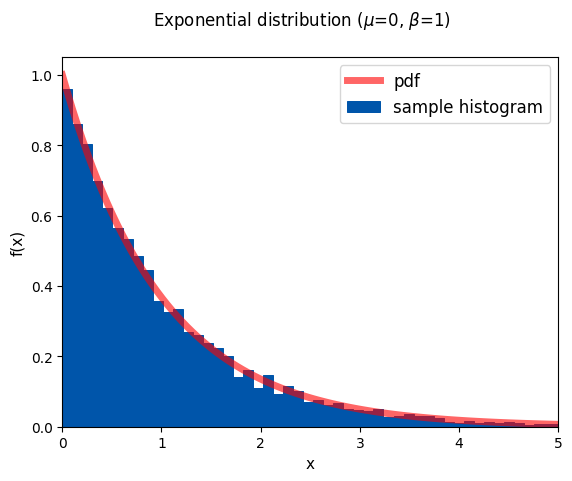

In [4]:
import numpy as np
from   scipy.stats import expon
import matplotlib.pyplot as plt
import seaborn as sns

mu   = 0 # loc
beta = 1 # rate parameter

fig, ax = plt.subplots(1, 1)

# Display the probability density function 
x = np.linspace(0, 5*(beta**2), 100)
ax.plot(x, expon.pdf(x, loc=mu, scale=1/beta), 'r-', lw=5, alpha=0.6, label='pdf')

# generate random numbers from expon(mu, beta) 
sample = expon.rvs(size=10000, loc=mu, scale=1/beta)

# plot the sample histogram
ax.set_xlim([x[0], x[-1]])
sns.histplot(ax=ax, data=sample, stat='density', discrete=False, kde=False,
            facecolor='#0055AA', edgecolor='#0055AA', label='sample histogram')
ax.set_ylabel('f(x)', fontsize=11)
ax.set_xlabel('x', fontsize=11)
fig.suptitle(f'Exponential distribution ($\\mu$={mu}, $\\beta$={beta})')
plt.legend(loc='upper right', fontsize= 12)
plt.show()

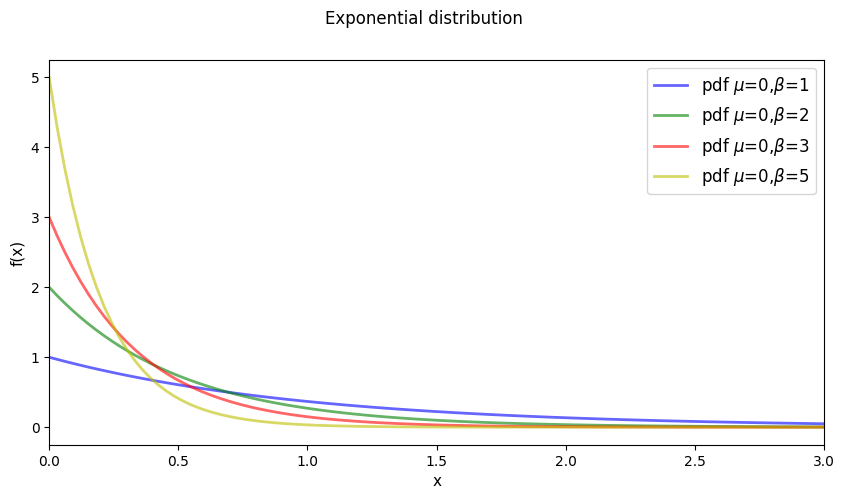

In [11]:
import numpy as np
from   scipy.stats import expon
import matplotlib.pyplot as plt
import seaborn as sns

mu      = 0
beta    = [1, 2, 3, 5]
color   = ['b', 'g', 'r', 'y']
fig, ax = plt.subplots(1, 1, figsize=(10,5))

x = np.linspace(0, 3, 100)

# Display the probability density functions
for n, b in enumerate(beta):
    ax.plot(x, expon.pdf(x, loc=mu, scale=1/b), color=color[n], lw=2, alpha=0.6, label=f'pdf $\\mu$={mu},$\\beta$={b}')

ax.set_xlim([x[0], x[-1]])
ax.set_ylabel('f(x)', fontsize=11)
ax.set_xlabel('x', fontsize=11)
fig.suptitle(f'Exponential distribution')
plt.legend(loc='upper right', fontsize= 12)
plt.show()

### 11. Chi-squared Distribution

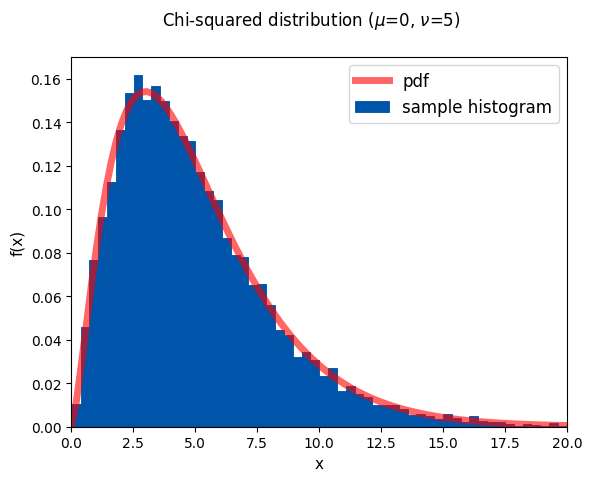

In [14]:
import numpy as np
from   scipy.stats import chi2
import matplotlib.pyplot as plt
import seaborn as sns

df  = 5 # shape parameter 'nu' = degrees of freedom
mu  = 0 # loc

fig, ax = plt.subplots(1, 1)

# Display the probability density function 
x = np.linspace(0, 2*(2*df), 100)
ax.plot(x, chi2.pdf(x, df=df, loc=mu, scale=1), 'r-', lw=5, alpha=0.6, label='pdf')

# generate random numbers from chi2(mu, df) 
sample = chi2.rvs(size=10000, df=df, loc=mu, scale=1)

# plot the sample histogram
ax.set_xlim([x[0], x[-1]])
sns.histplot(ax=ax, data=sample, stat='density', discrete=False, kde=False,
            facecolor='#0055AA', edgecolor='#0055AA', label='sample histogram')
ax.set_ylabel('f(x)', fontsize=11)
ax.set_xlabel('x', fontsize=11)
fig.suptitle(f'Chi-squared distribution ($\\mu$={mu}, $\\nu$={df})')
plt.legend(loc='upper right', fontsize= 12)
plt.show()

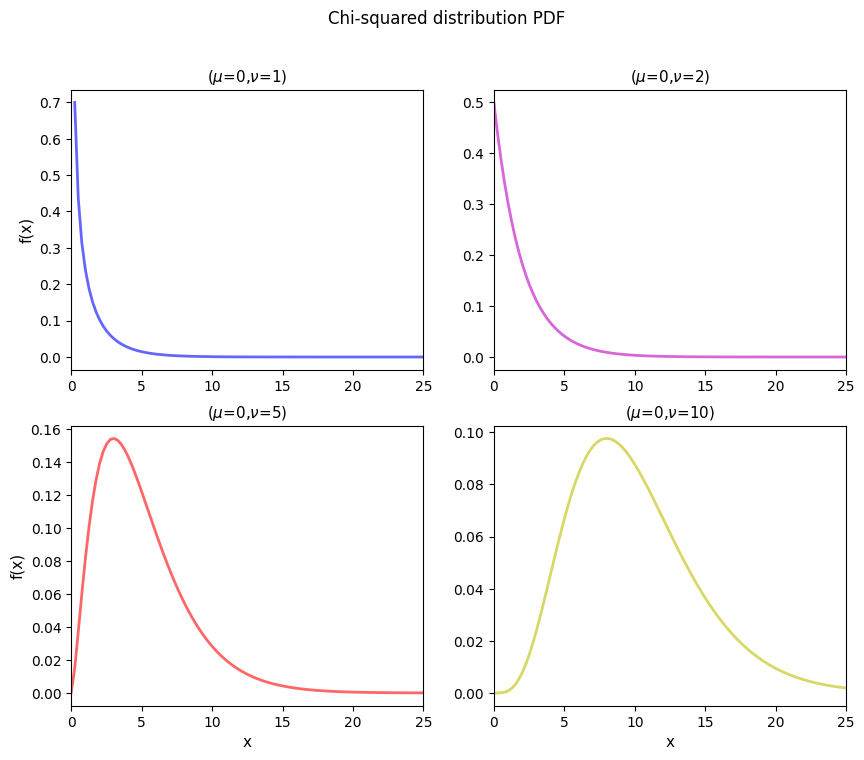

In [19]:
import numpy as np
from   scipy.stats import chi2
import matplotlib.pyplot as plt
import seaborn as sns

mu     = 0 # loc
df     = [[1, 2], [5, 10]] # degrees of freedom 'nu'
color  = [['b', 'm'], ['r', 'y']]
nrows  = 2
ncols  = 2

fig, ax = plt.subplots(nrows, ncols, figsize=(10,8))
x = np.linspace(0, 25, 100)

# Display the probability density functions
for nr in range(nrows):
    for nc in range(ncols):
        ax[nr][nc].plot(
            x,
            chi2.pdf(x, df=df[nr][nc], loc=mu, scale=1),
            color=color[nr][nc], 
            lw=2, 
            alpha=0.6, 
            label=f'pdf $\\mu$={mu},$\\nu$={df[nr][nc]}'
        )
        ax[nr][nc].set_xlim([x[0], x[-1]])
        if nc==0:
            ax[nr][nc].set_ylabel('f(x)', fontsize=11)
        if nr==nrows-1:
            ax[nr][nc].set_xlabel('x', fontsize=11)
        ax[nr][nc].set_title(
            f'($\\mu$={mu},$\\nu$={df[nr][nc]})', fontsize=11
        )
fig.suptitle(f'Chi-squared distribution PDF')
#plt.legend(loc='upper right', fontsize= 12)
plt.show()

### 12. t-distribution

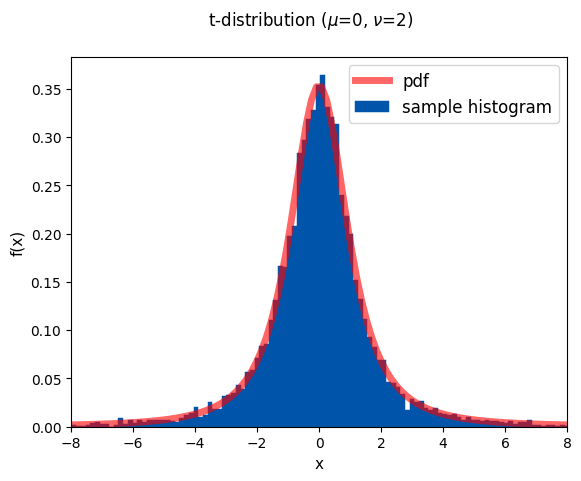

In [1]:
import numpy as np
from   scipy.stats import t
import matplotlib.pyplot as plt
import seaborn as sns

df  = 2 # shape parameter 'nu' = degrees of freedom
mu  = 0 # loc

fig, ax = plt.subplots(1, 1)

# Display the probability density function 
x = np.linspace(-8,8, 100)
ax.plot(x, t.pdf(x, df=df, loc=mu, scale=1), 'r-', lw=5, alpha=0.6, label='pdf')

# generate random numbers from t(mu,df) 
sample = t.rvs(size=10000, df=df, loc=mu, scale=1)

# plot the sample histogram
ax.set_xlim([x[0], x[-1]])
sns.histplot(ax=ax, data=sample, stat='density', discrete=False, kde=False,
            facecolor='#0055AA', edgecolor='#0055AA', label='sample histogram')
ax.set_ylabel('f(x)', fontsize=11)
ax.set_xlabel('x', fontsize=11)
fig.suptitle(f't-distribution ($\\mu$={mu}, $\\nu$={df})')
plt.legend(loc='upper right', fontsize= 12)
plt.show()

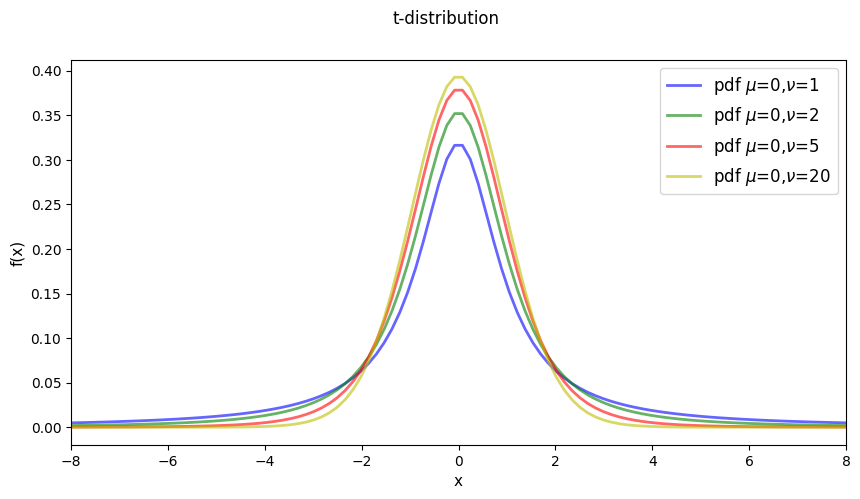

In [29]:
import numpy as np
from   scipy.stats import t
import matplotlib.pyplot as plt
import seaborn as sns

mu     = 0
df     = [1, 2, 5, 20]
color  = ['b', 'g', 'r', 'y', 'm']

fig, ax = plt.subplots(1, 1, figsize=(10,5))
x = np.linspace(-8, 8, 100)

# Display the probability density functions
for n, d in enumerate(df):
    ax.plot(x, t.pdf(x, df=d, loc=mu, scale=1), color=color[n], lw=2, alpha=0.6, label=f'pdf $\\mu$={mu},$\\nu$={d}')

ax.set_xlim([x[0], x[-1]])
ax.set_ylabel('f(x)', fontsize=11)
ax.set_xlabel('x', fontsize=11)
fig.suptitle(f't-distribution')
plt.legend(loc='upper right', fontsize= 12)
plt.show()